#### Dataset - df road collision of last 5 years
#### Target - finding the road accident severity rate (fatal/serious/slight)
#### these notebook is purely about exploratory nothing special

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [66]:
data = '..\\Data\\dft-road-casualty-statistics-collision-last-5-years.csv'
df = pd.read_csv(data)
print(df.info())
df.shape


<class 'pandas.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   503475 non-null  str    
 1   collision_year                                    503475 non-null  int64  
 2   collision_ref_no                                  503475 non-null  str    
 3   location_easting_osgr                             503410 non-null  float64
 4   location_northing_osgr                            503410 non-null  float64
 5   longitude                                         503410 non-null  float64
 6   latitude                                          503410 non-null  float64
 7   police_force                                      503475 non-null  int64  
 8   collision_severity                                503475 non-null  int64  
 9   number_of_vehic

(503475, 44)

In [20]:
df.describe()

,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,...,special_conditions_at_site,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
count,503475.000000,503410.000000,5.034100e+05,503410.000000,503410.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,...,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000,503475.000000
mean,2022.044942,455410.085521,2.749183e+05,-1.204486,52.361673,27.511884,2.751807,1.828675,1.272202,4.137183,...,0.166741,0.115557,2.483758,1.324958,1.478429,1.723106,1.522761,0.520693,0.236950,0.748171
std,1.390050,92797.773172,1.460445e+05,1.357086,1.315858,24.296055,0.465135,0.685515,0.698575,1.935444,...,1.542713,1.427455,13.651690,0.468716,0.764157,0.792647,2.678876,0.499572,0.406133,0.415392
min,2020.000000,65947.000000,1.021100e+04,-7.497375,49.912210,1.000000,1.000000,1.000000,1.000000,1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000
25%,2021.000000,392836.250000,1.750000e+05,-2.108384,51.461046,4.000000,3.000000,1.000000,1.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,-1.000000,0.000000,0.000000,0.809562
50%,2022.000000,461820.500000,2.143570e+05,-1.086891,51.811436,22.000000,3.000000,2.000000,1.000000,4.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,3.000000,1.000000,0.000000,1.000000
75%,2023.000000,529754.000000,3.818590e+05,-0.130722,53.328497,45.000000,3.000000,2.000000,1.000000,6.000000,...,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,3.000000,1.000000,0.157065,1.000000
max,2024.000000,655345.000000,1.184351e+06,1.759829,60.541144,99.000000,3.000000,26.000000,70.000000,7.000000,...,9.000000,9.000000,99.000000,3.000000,3.000000,2.000000,7.000000,1.000000,1.000000,1.000000


##### special_conditions_at_site      carriageway_hazards_historic       carriageway_hazards      urban_or_rural_area did_police_officer_attend_scene_of_accident      trunk_road_flag        enhanced_severity_collision
##### these are the column which has -1 and mostly are waste 
##### need the special_conditions_at_site , carriageway_hazards , urban_or_rural_area need to fix missing values of these one

In [21]:
df.head(11)

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,2021170H10421,2021,170H10421,447098.0,532997.0,-1.270905,54.689833,17,3,2,...,0,0,2,1,2,E01011959,-1,0,0.293588,0.706412
1,2021170H11231,2021,170H11231,450486.0,533118.0,-1.218333,54.690592,17,3,2,...,0,0,1,2,2,E01011973,-1,0,0.017448,0.982552
2,2020170M11750,2020,170M11750,449694.0,519733.0,-1.232884,54.570397,17,3,2,...,0,0,1,1,2,E01012092,-1,0,0.128730,0.871270
3,2021170M31761,2021,170M31761,449744.0,514217.0,-1.233040,54.520825,17,3,1,...,0,0,2,1,2,E01032553,-1,0,0.182698,0.817302
4,2021170S10441,2021,170S10441,445971.0,520834.0,-1.290292,54.580641,17,3,3,...,0,13,2,1,1,E01012258,-1,0,0.016094,0.983906
5,2022170S10952,2022,170S10952,443914.0,521309.0,-1.322030,54.585081,17,3,2,...,0,0,1,1,2,E01012193,-1,0,0.040685,0.959315
6,2021111119419,2021,111119419,428183.0,512452.0,-1.566280,54.506615,11,2,1,...,0,0,2,1,2,E01012338,7,1,1.000000,0.000000
7,2022111155778,2022,111155778,428907.0,516974.0,-1.554649,54.547202,11,3,2,...,0,0,1,3,2,E01012323,3,1,0.000000,1.000000
8,2022111200178,2022,111200178,428024.0,514803.0,-1.568504,54.527742,11,2,2,...,0,0,1,1,2,E01012316,7,1,1.000000,0.000000
9,2020070754597,2020,070754597,346215.0,384069.0,-2.809451,53.350775,7,3,2,...,0,0,2,1,2,E01012391,-1,0,0.121115,0.878885


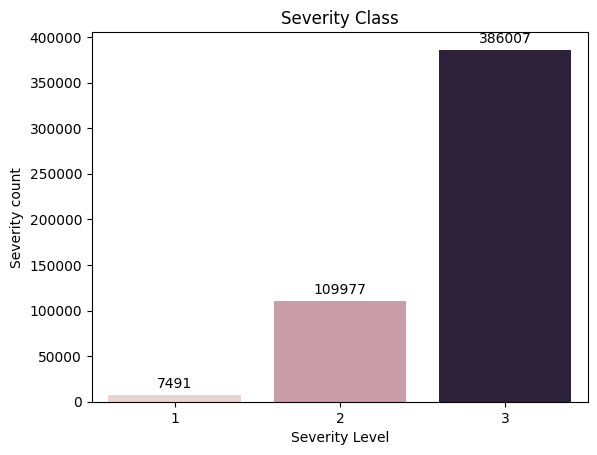

In [50]:
col_sev = df['collision_severity'].value_counts()
ax=sns.barplot(x=col_sev.index,y=col_sev.values,hue=col_sev.values,legend=False)
for container in ax.containers:
    ax.bar_label(container,padding=3)
plt.title("Severity Class")
plt.xlabel('Severity Level')
plt.ylabel('Severity count')
plt.show()

In [71]:
df['collision_severity'].value_counts(normalize=True).mul(100).round(2).sort_index()

collision_severity
1     1.49
2    21.84
3    76.67
Name: proportion, dtype: float64

In [52]:
missing_val = df.isnull().sum()*100/len(df)
print(missing_val)

collision_index                                     0.00000
collision_year                                      0.00000
collision_ref_no                                    0.00000
location_easting_osgr                               0.01291
location_northing_osgr                              0.01291
longitude                                           0.01291
latitude                                            0.01291
police_force                                        0.00000
collision_severity                                  0.00000
number_of_vehicles                                  0.00000
number_of_casualties                                0.00000
date                                                0.00000
day_of_week                                         0.00000
time                                                0.00000
local_authority_district                            0.00000
local_authority_ons_district                        0.00000
local_authority_highway                 

##### Checking if there is any -1 values 

In [55]:
(df == -1).sum()*100/len(df)

collision_index                                      0.000000
collision_year                                       0.000000
collision_ref_no                                     0.000000
location_easting_osgr                                0.000000
location_northing_osgr                               0.000000
longitude                                            0.000000
latitude                                             0.000000
police_force                                         0.000000
collision_severity                                   0.000000
number_of_vehicles                                   0.000000
number_of_casualties                                 0.000000
date                                                 0.000000
day_of_week                                          0.000000
time                                                 0.000000
local_authority_district                            82.044391
local_authority_ons_district                         0.000000
local_au

there is a lot more -1 than NaN vlaues 


In [65]:
print(f"{'Column':<55} {'Dtype':<10} {'Unique':<10}")
print("-" * 75)
for col in df.columns:
    print(f"{col:<55} {str(df[col].dtype):<10} {df[col].nunique():<10}")

Column                                                  Dtype      Unique    
---------------------------------------------------------------------------
collision_index                                         str        503475    
collision_year                                          int64      5         
collision_ref_no                                        str        501768    
location_easting_osgr                                   float64    242322    
location_northing_osgr                                  float64    259651    
longitude                                               float64    454018    
latitude                                                float64    432768    
police_force                                            int64      44        
collision_severity                                      int64      3         
number_of_vehicles                                      int64      19        
number_of_casualties                                    int64     

In [ ]:
print(df['collision_year'].value_counts().sort_index())

collision_year
2022    106004
2023    104258
2021    101087
2024    100927
2020     91199
Name: count, dtype: int64


In [62]:
print(df['date'].head(5).to_list())
print(df['time'].head(5).to_list())
df.info()

['22/05/2021', '20/10/2021', '01/12/2020', '09/12/2021', '12/04/2021']
['22:44', '15:50', '18:00', '16:55', '09:02']
<class 'pandas.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   503475 non-null  str    
 1   collision_year                                    503475 non-null  int64  
 2   collision_ref_no                                  503475 non-null  str    
 3   location_easting_osgr                             503410 non-null  float64
 4   location_northing_osgr                            503410 non-null  float64
 5   longitude                                         503410 non-null  float64
 6   latitude                                          503410 non-null  float64
 7   police_force                                      503475 n

In [64]:
key_cols = ['day_of_week','road_type','speed_limit','light_conditions','weather_conditions','road_surface_conditions','urban_or_rural_area',]
for cols in key_cols:
    print(df[cols].value_counts().sort_index())

day_of_week
1    56899
2    69140
3    73216
4    74866
5    76706
6    83389
7    69259
Name: count, dtype: int64
road_type
1     29963
2     11118
3     74715
6    365844
7      8722
9     13113
Name: count, dtype: int64
speed_limit
-1         15
 20     79234
 30    269912
 40     43731
 50     21836
 60     61402
 70     27345
Name: count, dtype: int64
light_conditions
-1        19
 1    359837
 4    104155
 5      3671
 6     26591
 7      9202
Name: count, dtype: int64
weather_conditions
-1        13
 1    400956
 2     57187
 3      1741
 4      5158
 5      5958
 6       292
 7      2296
 8     15270
 9     14604
Name: count, dtype: int64
road_surface_conditions
-1      3209
 1    361287
 2    124500
 3      1261
 4      6171
 5       821
 9      6226
Name: count, dtype: int64
urban_or_rural_area
-1         8
 1    339903
 2    163504
 3        60
Name: count, dtype: int64


##### What have we done here:
###### firstly these notebook is only for data analysis to check what missing values are there , target column value counts and percentage , standard Nan check , and other important stuff that we saw before doing any other stuff so we will get the idea how much we need to clean it .
these all the findings we found